In [ ]:
%%capture

!pip install langchain langchain_groq langgraph==0.0.187 python-dotenv langchain-community

In [ ]:
from google.colab import userdata
from langchain_groq import ChatGroq

# Get the Groq API key from Colab secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
llm = ChatGroq(model="llama-3.1-8b-instant", groq_api_key=GROQ_API_KEY)

In [ ]:
import os, json
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated, Literal
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from pydantic import BaseModel
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

/tmp/ipykernel_16295/1237901838.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
# Create the .env file with your variables

with open('.env', 'w') as f:
    f.write('groq_api_key=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\n')

load_dotenv()

llm = ChatGroq(model="llama-3.1-8b-instant", groq_api_key=os.getenv("groq_api_key"))
#environment LLM key


In [ ]:
class OnboardingState(TypedDict):
  # Input
  hire_data:dict  # {name, role, dept, start_date, email}
  # Set by ResumeParser
  parsed_profile:dict   # {role_level, skills_needed, team, manager}
  # Set by OfferGenenerator agent (can be updated by revision loop)
  offer_draft: str                # Offer letter text
  revision_count: int             # Tracks number of revision loops
  revision_note: str              # Manager's feedback for revision

  # Set by HITL Approval node
  approval_decision: Literal["approve", "revise", "pending"]

  # Set by IT Provisioner
  it_tasks: list          # [laptop, email, Jira Access]

  # Set by AuditLogger
  audit_log: list         # Timestamped even trail for compliance

In [ ]:
# ── Sample new hires dataset ───────────────────────────────────────────────

new_hires_dataset = [
    {
        "name":       "Sneha Iyer",
        "role":       "Senior Data Engineer",
        "dept":       "Engineering",
        "start_date": "2024-09-01",
        "email":      "sneha.iyer@company.com",
        "salary_band":"L5"
    },
    {
        "name":       "John Doe",
        "role":       "Software Engineer",
        "dept":       "Engineering",
        "start_date": "2024-09-15",
        "email":      "john.doe@company.com",
        "salary_band":"L4"
    },
    {
        "name":       "Jane Smith",
        "role":       "Marketing Specialist",
        "dept":       "Marketing",
        "start_date": "2024-10-01",
        "email":      "jane.smith@company.com",
        "salary_band":"L3"
    },
    {
        "name":       "David Lee",
        "role":       "HR Business Partner",
        "dept":       "HR",
        "start_date": "2024-10-15",
        "email":      "david.lee@company.com",
        "salary_band":"L5"
    },
    {
        "name":       "Maria Garcia",
        "role":       "Product Manager",
        "dept":       "Product",
        "start_date": "2024-11-01",
        "email":      "maria.garcia@company.com",
        "salary_band":"L6"
    }
]

# For compatibility with existing graph execution that processes one hire
new_hire = new_hires_dataset[0]

In [ ]:
# Checkpointer persists state between graph runs (required for HITL)

checkpointer = MemorySaver()

#Each new hire gets a unique thread_id - allows concurret onboarding
thread_config = {"configurable" : {"thread_id": "hire-2024-001"}}


In [ ]:
# ── Cell 3: Automated Agent Nodes ────────────────────────────────

def orchestrator_agent(state: OnboardingState) -> dict:
    hire = state["hire_data"]
    print(f"\n[Orchestrator] Starting onboarding for: {hire['name']} ({hire['role']})")
    return {
        "revision_count": 0,
        "revision_note": "",
        "approval_decision": "pending",
        "audit_log": [f"[STARTED] Onboarding initiated for {hire['name']}"]
    }

def resume_parser_agent(state: OnboardingState) -> dict:
    hire = state["hire_data"]
    # Production: parse actual resume PDF + job spec
    profile = {
        "role_level": hire.get("salary_band", "L4"),
        "team": "Data Platform Team",
        "manager": "Rahul Sharma (VP Engineering)",
        "skills_needed": ["Spark", "dbt", "Airflow", "Python"],
        "probation_months": 3
    }
    print(f"  [ResumeParser] Profile parsed: {profile['role_level']} → {profile['team']}")
    log = state["audit_log"] + ["[PARSED] Role profile extracted"]

    return {"parsed_profile": profile, "audit_log": log}

def offer_generator_agent(state: OnboardingState) -> dict:
    hire = state["hire_data"]
    profile = state["parsed_profile"]
    revision_note = state.get("revision_note", "")
    count = state.get("revision_count", 0)
    revision_context = f"\n\nRevision feedback from manager: {revision_note}" if revision_note else ""
    prompt = f"""
    Draft a professional employee offer letter for:
    Name: {hire['name']}  |  Role: {hire['role']}  |  Dept: {hire['dept']}
    Start: {hire['start_date']}  |  Level: {profile['role_level']}
    Reporting to: {profile['manager']}  |  Team: {profile['team']}
    Include: welcome message, role summary, start logistics, benefits note.
    Keep it under 250 words. Professional but warm tone.{revision_context}
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content
    log = state["audit_log"] + [f"[DRAFT] Offer letter generated (revision #{count})"]
    print(f"  [OfferGenerator] Draft ready (attempt #{count + 1})")
    return {"offer_draft": draft, "audit_log": log}

In [ ]:
#Homework : Write the candidate HITL node also.

In [ ]:
# Cell 4: HITL Approval Node

def hitl_approval_node(state: OnboardingState) -> Command:
  """
  HITL Node - pauses graphs, waits for human decision.
  The interrupt() call serializes state to checkpointer and raises a
  GraphInterrupt exception, suspending execution.
  When the human submits their decision, Command(resume=...) restarts
  from THIS exact node with their inpur available.
  """
  draft = state["offer_draft"]
  hire_name = state["hire_data"]["name"]

  print(f"\n────────────────────────────────────────────────────────────")
  print(f"  [HITL]   Pausing for manager approval...")
  print(f"  [HITL] Offer draft for {hire_name}:")
  print(f"  {draft[:200]}...") # Print only a snippet

  # 1. TRIGGER INTERRUPT
  manager_input = interrupt({
      "question": f"Review offer for {hire_name}",
      "offer_draft": draft,
      "instructions": "Respond with {'decision': 'approve'} or {'decision': 'revise', 'note': '...'}"
  })

  print(f"  [HITL] After interrupt. Manager input received: {manager_input}") # Debug print
  print(f"  [HITL] Type of manager_input: {type(manager_input)}") # Debug print

  # 2. HANDLE "REVISE" DECISION
  decision = manager_input.get("decision")
  if decision == "revise":
      revision_note = manager_input.get("note", "No specific note provided.")
      print(f"  [HITL] Manager requested revision: {revision_note}")
      return Command(
          update={
              "revision_count": state["revision_count"] + 1,
              "revision_note": revision_note,
              "approval_decision": "revise",
              "audit_log": state["audit_log"] + [f"[MANAGER] Revision requested: {revision_note}"]
          },
          goto="offer_generator_agent"
      )

  # 3. HANDLE "APPROVE" DECISION
  elif decision == "approve":
      print(f"  [HITL] Manager approved offer for {hire_name}. Proceeding to IT provisioner.") # Modified print
      return Command(
          update={"approval_decision": "approve",
                  "audit_log": state["audit_log"] + ["[MANAGER] Offer approved"]},
          goto="it_provisioner_agent" # Go to IT provisioner after approval
      )
  else:
      # Should not happen in a well-defined workflow
      print(f"  [HITL] Invalid decision from manager: {decision}. Pausing again.")
      return interrupt("Invalid decision, please provide 'approve' or 'revise'.")


In [ ]:
# Cell 5 : Post-Approval nodes

def it_provisioner_agent(state: OnboardingState)-> dict:
  print("  [IT Provisioner Agent] --- EXECUTING --- ")
  print(f"  [IT Provisioner Agent] State received: {state.get('approval_decision')=}, {state.get('parsed_profile')=}")
  hire = state["hire_data"]
  profile = state["parsed_profile"]
  # Map department + role to required IT access
  dept_tools = {
      "Engineering": ["Laptop (MacBook Pro)", "GitHub Org access",
                      "AWS IAM role (developer)", "Jira + Confluence",
                      "Datadog read access"],
      "Sales":       ["Laptop (Windows)", "Salesforce CRM", "ZoomInfo"],
      "HR":          ["Laptop", "Workday access", "BambooHR"]
  }

  base_tools = ["Corporate email", "Slack workspace",
                "Google Workspace", "1Password", "Okta SSO"]

  dept  = hire.get("dept", "Engineering")
  tasks = base_tools + dept_tools.get(dept, [])
  print(f"  [IT Provisioner] Provisioning {len(tasks)} items for {hire['name']}")
  log = state["audit_log"] + [f"[IT] {len(tasks)} access items provisioned"]
  return {"it_tasks": tasks, "audit_log": log}

In [ ]:
from typing import Literal, List
from langgraph.types import Command, interrupt

def compliance_review_node(state: OnboardingState) -> Command:
    print("  [Compliance Review Node] --- EXECUTING --- ")
    """
    Interrupts for Legal/Compliance approval of IT tasks.
    Removes restricted items or proceeds to audit logging.
    """
    it_tasks = state.get("it_tasks", [])
    print(f"  [Compliance Review Node] Current IT tasks for review: {it_tasks}")

    # 1. TRIGGER INTERRUPT
    # This pauses the graph and displays the IT tasks to the reviewer.
    # The 'review_input' will contain the user's decision and items to remove.
    review_input = interrupt({
        "question": "Review IT Access Permissions (AWS IAM & Data Access)",
        "it_tasks_to_review": it_tasks,
        "instructions": "Respond with {'decision': 'approve'} or {'decision': 'restrict', 'remove': ['item1', 'item2']}"
    })

    decision = review_input.get("decision")
    items_to_remove = review_input.get("remove", [])

    # 2. HANDLE "RESTRICT" DECISION
    if decision == "restrict":
        # Filter out the flagged items from the current it_tasks list
        updated_tasks = [task for task in it_tasks if task not in items_to_remove]

        # Log the restriction event
        restriction_note = f"Compliance restricted access to: {', '.join(items_to_remove)}"
        new_log = {"event": "Compliance Restriction", "details": restriction_note}

        # Update state and loop back to IT Provisioner (or stay at current node for re-review)
        return Command(
            update={
                "it_tasks": updated_tasks,
                "audit_log": state.get("audit_log", []) + [new_log]
            },
            goto="it_provisioner_agent" # Corrected typo: "it_provisioner" to "it_provisioner_agent"
        )

    # 3. HANDLE "APPROVE" DECISION
    # On approval, proceed directly to the audit_logger_node
    approval_log = {"event": "Compliance Approved", "details": "All IT tasks approved."}

    return Command(
        update={
            "audit_log": state.get("audit_log", []) + [approval_log]
        },
        goto="audit_logger_node"
    )

In [ ]:
def audit_logger_node(state: OnboardingState) -> OnboardingState:
    print("  [Audit Logger] --- EXECUTING --- ")
    hire_name = state["hire_data"]["name"]
    log = state["audit_log"] + [f"[AUDIT] Onboarding for {hire_name} completed."]
    print(f"  [Audit Logger] Finalizing audit for {hire_name}.")
    return {"audit_log": log}


In [ ]:
final_state = app.get_state(config=thread_config)
print("\n--- Final Audit Log ---")
if final_state and final_state.values.get('audit_log'):
    for entry in final_state.values['audit_log']:
        print(f"  - {entry}")
else:
    print("  Audit log not found or empty.")


--- Final Audit Log ---
  - [STARTED] Onboarding initiated for Sneha Iyer
  - [PARSED] Role profile extracted
  - [DRAFT] Offer letter generated (revision #0)


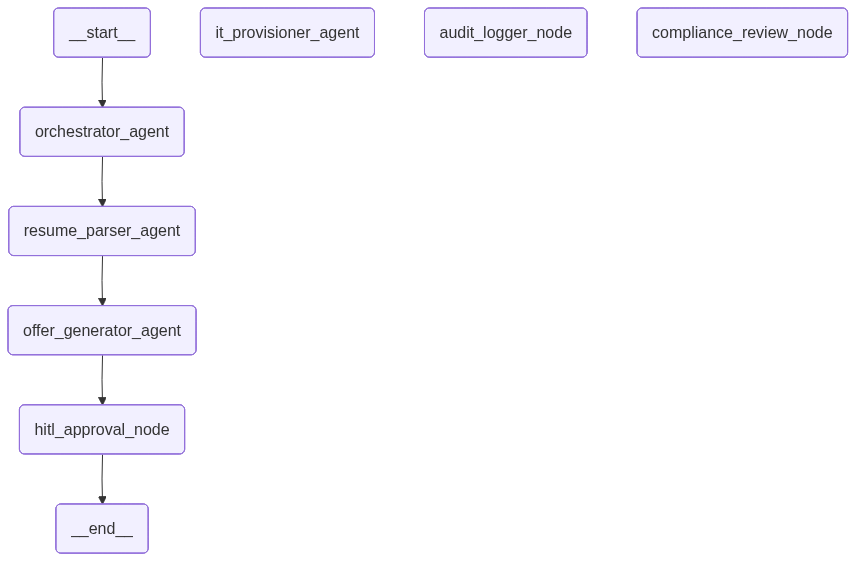

Graph compiled with checkpointer. HITL interrupts enabled.


In [ ]:
# Cell 6 : Build Graph

# ── Cell 6: Build Graph ───────────────────────────────────────────

graph = StateGraph(OnboardingState)

# Add nodes
graph.add_node("orchestrator_agent",   orchestrator_agent)
graph.add_node("resume_parser_agent",   resume_parser_agent)
graph.add_node("offer_generator_agent", offer_generator_agent)
graph.add_node("hitl_approval_node",    hitl_approval_node)   # ← HITL
graph.add_node("it_provisioner_agent",  it_provisioner_agent)
graph.add_node("audit_logger_node",     audit_logger_node)

# Wire sequential flow
graph.add_edge(START,                    "orchestrator_agent")
graph.add_edge("orchestrator_agent",    "resume_parser_agent")
graph.add_edge("resume_parser_agent",   "offer_generator_agent")
graph.add_edge("offer_generator_agent", "hitl_approval_node")

# NOTE: hitl_approval_node uses Command to route — no add_conditional_edges needed
graph.add_edge("audit_logger_node",     END)

# 1. Insert compliance_review_node
graph.add_node("compliance_review_node", compliance_review_node)

# 2. Wire: it_provisioner → compliance_review → audit_logger
graph.add_edge("it_provisioner_agent", "compliance_review_node")
graph.add_edge("compliance_review_node", "audit_logger_node")

# Compile WITH checkpointer (required for interrupt/resume)
app = graph.compile(checkpointer=checkpointer)

# Visualise the graph
display(Image(app.get_graph().draw_mermaid_png()))
print("Graph compiled with checkpointer. HITL interrupts enabled.")

In [ ]:
# Cell 7: First RUN - graph runs until interrupt()

# ── Cell 7a: FIRST RUN — graph runs until interrupt() ────────────
initial_state = {
    "hire_data":        new_hire,
    "parsed_profile":   {},
    "offer_draft":      "",
    "revision_count":   0,
    "revision_note":    "",
    "approval_decision":"pending",
    "it_tasks":         [],
    "audit_log":        []
}

print(" Starting onboarding graph...")

try:
    result = app.invoke(initial_state, config=thread_config)

except Exception as e:
    print(f"\n  Graph paused at HITL node.")
    print(f"   State saved. Waiting for manager input...")

The graph is currently paused. To continue, we need to provide input for the `hitl_approval_node` to 'approve' the offer letter. After approval, the graph should proceed to the `it_provisioner_agent` and then to the `compliance_review_node`, where it will pause again.

In [ ]:
import traceback

# Cell 8: Resume graph after HITL approval

print("Resuming graph with HITL approval...")

# Define mock_hitl_input explicitly here to ensure it's available
mock_hitl_input = {"decision": "approve"}

# Define mock_compliance_input for resuming at compliance_review_node
mock_compliance_input = {"decision": "approve"}

# --- ENSURE GRAPH IS IN PAUSED STATE (equivalent to running Cell 7 again if needed) ---
print("\n--- Initializing/Ensuring Graph State ---")
try:
    # Check if there's an existing state for this thread_id
    state_snapshot = app.get_state(config=thread_config)
    if not state_snapshot.values: # If the values dictionary is empty, no state exists
        print("  No existing state found for this thread. Running initial graph execution...")
        initial_state = {
            "hire_data":        new_hire, # new_hire needs to be available in the kernel
            "parsed_profile":   {},
            "offer_draft":      "",
            "revision_count":   0,
            "revision_note":    "",
            "approval_decision":"pending",
            "it_tasks":         [],
            "audit_log":        []
        }
        # Run the initial invocation to populate the state and pause at HITL
        app.invoke(initial_state, config=thread_config)
        print("  Initial graph execution completed, graph should now be paused at HITL node.")
        post_initial_state = app.get_state(config=thread_config)
        print(f"  State after initial run: {post_initial_state.next=}, audit_log last entry: {post_initial_state.values.get('audit_log', [])[-1] if post_initial_state.values.get('audit_log') else 'N/A'}")
    else:
        print("  Existing state found for this thread. Proceeding with resume.")

except Exception as e:
    print(f"  Error during initial state check/run: {type(e).__name__} - {e}")
    traceback.print_exc()
    print("  Proceeding with resume, but initial state may be incorrect or graph might not be paused.")


# --- Stage 1: Resume from HITL Approval Node ---
print("\n--- Stage 1: Resuming from HITL Approval Node ---")
try:
    print("\nState before first resume (expecting pause at HITL node):")
    state_before_hitl_resume = app.get_state(config=thread_config)
    print(f"  Full state object before HITL resume: {state_before_hitl_resume}") # Keep for detailed debug
    print(f"  State before HITL resume: {state_before_hitl_resume.next=}, audit_log last entry: {state_before_hitl_resume.values.get('audit_log', [])[-1] if state_before_hitl_resume.values.get('audit_log') else 'N/A'}")

    for key, value in state_before_hitl_resume.values.items():
        if key not in ['offer_draft']:
            print(f"  {key}: {value}")

    print(f"\nAttempting to resume HITL node with input: {mock_hitl_input}")
    # Resume by passing None as input, and the resume data in config['output']
    result_after_hitl_resume = app.invoke(
        None,  # Signal resume without directly providing input as initial state
        config={**thread_config, "output": mock_hitl_input}
    )
    current_state_after_hitl_invoke = app.get_state(config=thread_config)
    print(f"  State AFTER HITL invoke: {current_state_after_hitl_invoke.next=}, audit_log last entry: {current_state_after_hitl_invoke.values.get('audit_log', [])[-1] if current_state_after_hitl_invoke.values.get('audit_log') else 'N/A'}")

    print("\nResult of app.invoke after HITL resume (if no further interrupt):")
    for key, value in result_after_hitl_resume.items():
        if key not in ['offer_draft']:
            print(f"  {key}: {value}")

except Exception as e:
    print(f"\n  Exception during first invoke (resuming HITL): {type(e).__name__} - {e}")
    traceback.print_exc()
    print(f"\n  Graph should now be paused at compliance_review_node (as expected).")
    print(f"   State saved. Waiting for compliance input...")

# --- Stage 2: Resume from Compliance Review Node (if paused there) ---
print("\n--- Stage 2: Attempting to resume from Compliance Review Node ---")
try:
    print("\nState before second resume (expecting pause at Compliance node):")
    state_before_compliance_resume = app.get_state(config=thread_config)
    print(f"  Full state object before Compliance resume: {state_before_compliance_resume}") # Keep for detailed debug
    print(f"  State before Compliance resume: {state_before_compliance_resume.next=}, audit_log last entry: {state_before_compliance_resume.values.get('audit_log', [])[-1] if state_before_compliance_resume.values.get('audit_log') else 'N/A'}")

    for key, value in state_before_compliance_resume.values.items():
        if key not in ['offer_draft']:
            print(f"  {key}: {value}")

    print(f"\nAttempting to resume Compliance node with input: {mock_compliance_input}")
    # Resume by passing None as input, and the resume data in config['output']
    result_after_compliance_resume = app.invoke(
        None, # Signal resume without directly providing input as initial state
        config={**thread_config, "output": mock_compliance_input}
    )
    current_state_after_compliance_invoke = app.get_state(config=thread_config)
    print(f"  State AFTER Compliance invoke: {current_state_after_compliance_invoke.next=}, audit_log last entry: {current_state_after_compliance_invoke.values.get('audit_log', [])[-1] if current_state_after_compliance_invoke.values.get('audit_log') else 'N/A'}")

    print("\nResult of app.invoke after Compliance resume (if no further interrupt):")
    for key, value in result_after_compliance_resume.items():
        if key not in ['offer_draft']:
            print(f"  {key}: {value}")

except Exception as e:
    print(f"\n  Exception during second invoke (resuming Compliance): {type(e).__name__} - {e}")
    traceback.print_exc()
    print(f"\n  Graph may have paused again or completed with error.")

# Display final current state
print("\n--- Final Current State after all resumes ---")
try:
    final_state = app.get_state(config=thread_config)
    print(f"  Full final state object: {final_state}") # Keep for detailed debug
    print(f"  Final State: {final_state.next=}, audit_log last entry: {final_state.values.get('audit_log', [])[-1] if final_state.values.get('audit_log') else 'N/A'}")

    for key, value in final_state.values.items():
        if key not in ['offer_draft']:
            print(f"  {key}: {value}")
except Exception as e:
    print(f"  Error getting final state: {type(e).__name__} - {e}")
    traceback.print_exc()


Resuming graph with HITL approval...

--- Initializing/Ensuring Graph State ---
  Existing state found for this thread. Proceeding with resume.

--- Stage 1: Resuming from HITL Approval Node ---

State before first resume (expecting pause at HITL node):
  Full state object before HITL resume: StateSnapshot(values={'hire_data': {'name': 'Sneha Iyer', 'role': 'Senior Data Engineer', 'dept': 'Engineering', 'start_date': '2024-09-01', 'email': 'sneha.iyer@company.com', 'salary_band': 'L5'}, 'parsed_profile': {'role_level': 'L5', 'team': 'Data Platform Team', 'manager': 'Rahul Sharma (VP Engineering)', 'skills_needed': ['Spark', 'dbt', 'Airflow', 'Python'], 'probation_months': 3}, 'offer_draft': '[Company Logo]\n[Company Name]\n[Date]\n\nSneha Iyer\n[Address]\n\nDear Sneha,\n\nWe are thrilled to extend an offer to you for the position of Senior Data Engineer in the Engineering department, effective September 1, 2024. This role will be a great addition to our Data Platform Team, and we are c

In [ ]:
# ── Extension Task ────────────────────────────────────────────────
#
# TODO 1: Add a `compliance_review_node` that interrupts for a
#         Legal/Compliance officer to approve IT access permissions
#         (especially AWS IAM roles and data access).
#
# TODO 2: The compliance gate should:
#   - Show the full it_tasks list to the reviewer
#   - Accept "approve" or "restrict" + a list of items to remove
#   - On "restrict": remove flagged items from it_tasks and re-log
#   - On "approve": proceed directly to audit_logger_node
#
# TODO 3: Update the graph:
#   - Insert compliance_review_node BETWEEN it_provisioner and audit_logger
#   - Wire: it_provisioner → compliance_review → audit_logger
#   - Recompile with the same checkpointer
#
# TODO 4: Test with two thread_ids:
#   - "hire-001" approved at compliance
#   - "hire-002" restricted (remove AWS IAM access)
#
# HINT: The compliance node follows the exact same interrupt/Command
# pattern as hitl_approval_node. Copy + adapt it.

def compliance_review_node(state: OnboardingState) -> Command:

    """Your implementation here"""

    pass

In [ ]:
# 1. Setup the initial state for the thread
hire_001_state = {
    "hire_data": {
        "name": "Sneha Iyer",
        "role": "Senior Data Engineer",
        "dept": "Engineering",
        "start_date": "2024-09-01",
        "email": "sneha.iyer@company.com",
        "salary_band": "L5"
    },
    "it_tasks": ["MacBook Pro", "Okta Access", "AWS IAM: DataEngineer-Role", "Redshift Read-Only"],
    "audit_log": [{"event": "IT_Provisioning", "timestamp": "2024-08-25T10:00:00"}]
}

# 2. Simulate the Compliance Officer's "approve" decision via the interrupt
# In a test suite, we provide the input that would normally come from the HITL UI
mock_hitl_input = {"decision": "approve"}

# 3. Execute the node logic (This line is incorrect for nodes with interrupt() and will be removed)
# result_command = compliance_review_node(hire_001_state)
# Note: In actual execution, the 'interrupt' would resume with mock_hitl_input


In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from copy import deepcopy

# Define dummy nodes for the targets that compliance_review_node might jump to.
# These simply pass the state through, or print a message indicating they were reached.
def dummy_it_provisioner_agent(state: OnboardingState) -> OnboardingState:
    print("  [Wrapper: Dummy IT Provisioner] Reached. State unchanged.")
    return state

def dummy_audit_logger_node(state: OnboardingState) -> OnboardingState:
    print("  [Wrapper: Dummy Audit Logger] Reached. State unchanged.")
    return state

def test_compliance_node_wrapper(initial_state: OnboardingState, resume_input: dict, thread_id: str = "test-compliance-thread") -> OnboardingState:
    """
    Wrapper function to test the compliance_review_node within a mock graph context.
    Simulates the graph's interrupt and resume mechanism.
    """
    print(f"\n--- Testing compliance_review_node with thread_id: {thread_id} ---")

    # Build a minimalistic graph that includes the compliance_review_node
    # and dummy nodes for its potential 'goto' targets.
    graph_builder = StateGraph(OnboardingState)
    graph_builder.add_node("compliance_review_node", compliance_review_node)
    graph_builder.add_node("it_provisioner_agent", dummy_it_provisioner_agent) # Dummy target for 'restrict'
    graph_builder.add_node("audit_logger_node", dummy_audit_logger_node)     # Dummy target for 'approve'

    # Set entry point to compliance_review_node
    graph_builder.set_entry_point("compliance_review_node")

    # Add edges to connect the compliance node's potential outputs to END via dummy nodes
    # The actual 'goto' in compliance_review_node will direct to 'it_provisioner_agent' or 'audit_logger_node'.
    # These dummy nodes then lead to END for this test graph.
    graph_builder.add_edge("it_provisioner_agent", END)
    graph_builder.add_edge("audit_logger_node", END)

    # Compile the graph with a memory checkpointer
    test_checkpointer = MemorySaver()
    test_thread_config = {"configurable": {"thread_id": thread_id}}
    app_test = graph_builder.compile(checkpointer=test_checkpointer)

    # 1. First invoke to hit the interrupt in compliance_review_node
    print(f"  [Wrapper] Initial invoke to hit interrupt...")
    try:
        app_test.invoke(initial_state, config=test_thread_config)
    except Exception as e:
        # We expect a GraphInterrupt here. LangGraph raises it when interrupt() is called.
        print(f"  [Wrapper] Caught expected exception: {type(e).__name__} (Graph paused).")

    # 2. Resume the graph with the provided input
    print(f"  [Wrapper] Resuming with input: {resume_input}")
    final_state_after_resume = app_test.invoke(
        None, # Pass None as input for resuming
        config={**test_thread_config, "output": resume_input} # Pass resume_input in config['output']
    )

    print(f"  [Wrapper] Final state after resume for thread '{thread_id}':")
    # Print relevant parts of the state for inspection
    for k, v in final_state_after_resume.items():
        if k not in ['offer_draft', 'parsed_profile', 'hire_data']: # Avoid printing large strings
            print(f"    {k}: {v}")
    print(f"--- Test complete for thread_id: {thread_id} ---")
    return final_state_after_resume


In [ ]:
# Example Usage of the wrapper function

# --- Test Case 1: Approve Decision ---
initial_state_approve = deepcopy(hire_001_state) # Use a copy of the existing hire_001_state
mock_approve_input = {"decision": "approve"}

print("\n===== Testing Compliance Node: APPROVE Scenario =====")
approved_state = test_compliance_node_wrapper(
    initial_state_approve,
    mock_approve_input,
    thread_id="compliance-test-001-approve"
)

# --- Test Case 2: Restrict Decision ---
initial_state_restrict = deepcopy(hire_001_state)
mock_restrict_input = {"decision": "restrict", "remove": ["AWS IAM: DataEngineer-Role"]}

print("\n===== Testing Compliance Node: RESTRICT Scenario =====")
restricted_state = test_compliance_node_wrapper(
    initial_state_restrict,
    mock_restrict_input,
    thread_id="compliance-test-002-restrict"
)



===== Testing Compliance Node: APPROVE Scenario =====

--- Testing compliance_review_node with thread_id: compliance-test-001-approve ---
  [Wrapper] Initial invoke to hit interrupt...
  [Compliance Review Node] --- EXECUTING --- 
  [Compliance Review Node] Current IT tasks for review: ['MacBook Pro', 'Okta Access', 'AWS IAM: DataEngineer-Role', 'Redshift Read-Only']
  [Wrapper] Resuming with input: {'decision': 'approve'}
  [Compliance Review Node] --- EXECUTING --- 
  [Compliance Review Node] Current IT tasks for review: ['MacBook Pro', 'Okta Access', 'AWS IAM: DataEngineer-Role', 'Redshift Read-Only']
  [Wrapper] Final state after resume for thread 'compliance-test-001-approve':
    it_tasks: ['MacBook Pro', 'Okta Access', 'AWS IAM: DataEngineer-Role', 'Redshift Read-Only']
    audit_log: [{'event': 'IT_Provisioning', 'timestamp': '2024-08-25T10:00:00'}]
    __interrupt__: [Interrupt(value={'question': 'Review IT Access Permissions (AWS IAM & Data Access)', 'it_tasks_to_review': ['